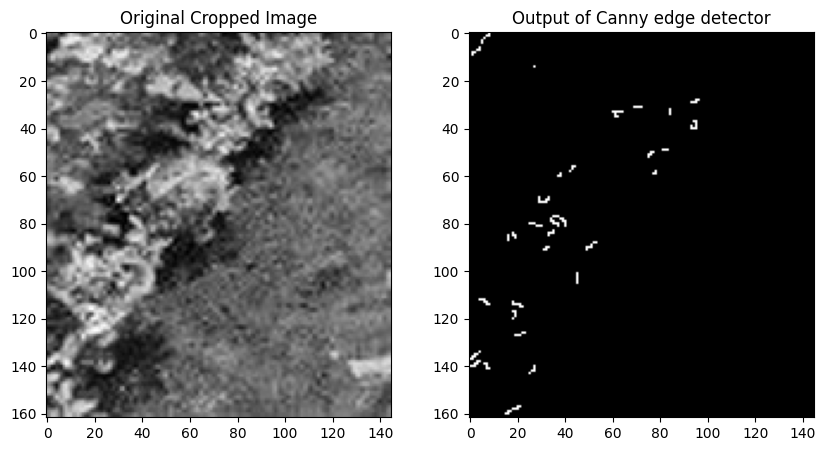

In [8]:


import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
from sklearn.linear_model import RANSACRegressor
# 01. Load the cropped image in grayscale
img = cv.imread(r'C:\Users\Nawam Perera\Downloads\Picture1c.jpg', cv.IMREAD_GRAYSCALE)

# Apply Canny edge detector with specified thresholds
edges = cv.Canny(img, 550, 690) # [cite: 14]

# Extract feature positions to x and y coordinates
indices = np.where(edges != 0) # [cite: 15]
x = indices[1] # [cite: 18]
y = indices[0] # [cite: 19]

y = img.shape[0] - y 

# Plot original and edge image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Cropped Image')
ax[1].imshow(edges, cmap='gray')
ax[1].set_title('Output of Canny edge detector')
plt.show()

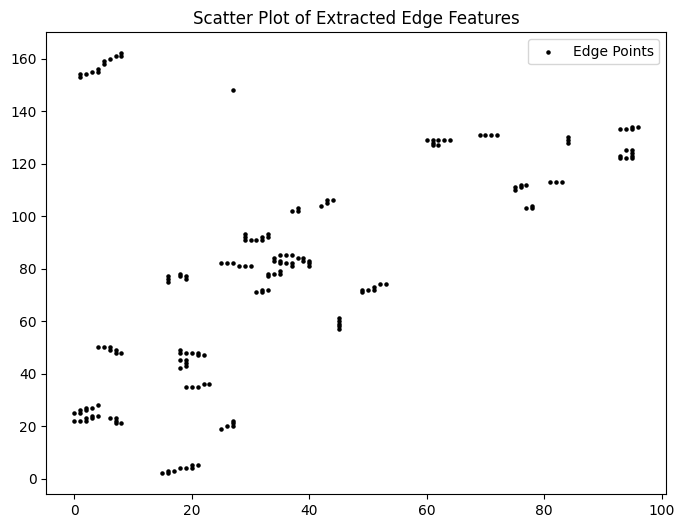

In [9]:
# 02.The scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=5, c='black', label='Edge Points')
plt.title('Scatter Plot of Extracted Edge Features')
plt.legend()
plt.show()

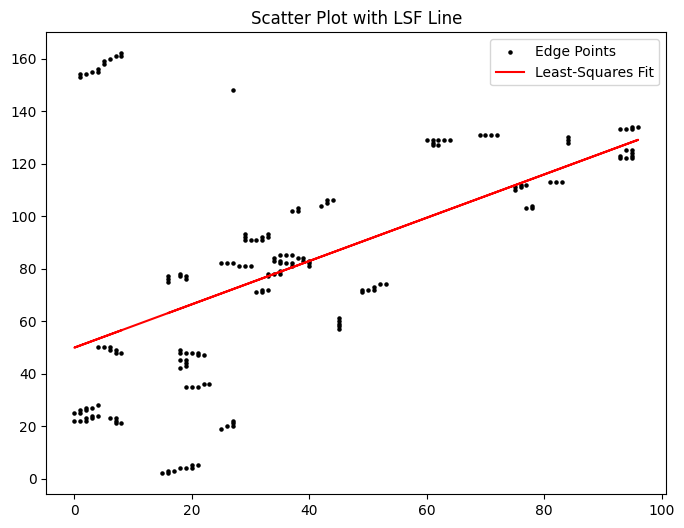

In [11]:
# 03 LSF
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=5, c='black', label='Edge Points')
coefficients_lsf = np.polyfit(x, y, 1)
m_lsf, c_lsf = coefficients_lsf
y_lsf = m_lsf * x + c_lsf
plt.plot(x, y_lsf, color='red', label='Least-Squares Fit')
plt.title('Scatter Plot with LSF Line')
plt.legend()
plt.show()

In [12]:
# 04. Angle Calculation
angle_lsf_rad = np.arctan(m_lsf)
angle_lsf_deg = np.degrees(angle_lsf_rad)
print(f"LSF Estimated Angle: {angle_lsf_deg:.2f} degrees")

LSF Estimated Angle: 39.50 degrees


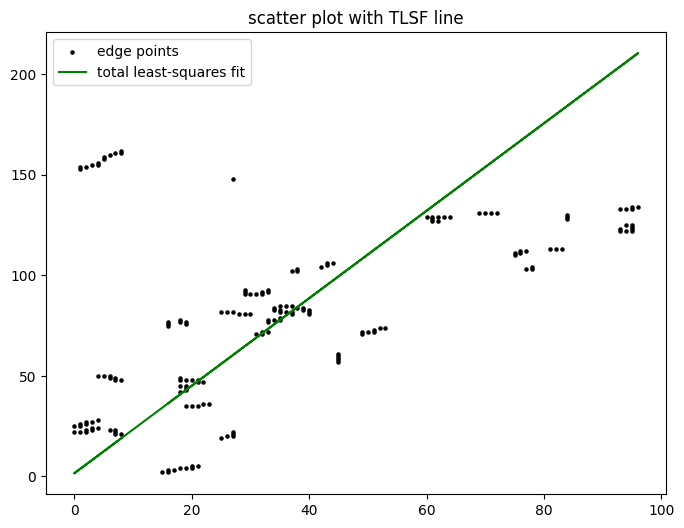

In [ ]:
# 6. TLF (Orthogonal Distance Regression) 
def linear_func(p, x): 
    m, c = p 
    return m * x + c 

linear_model = odr.Model(linear_func) 
data = odr.Data(x, y) 

# Provide initial guess from LSF results 
odr_obj = odr.ODR(data, linear_model, beta0=[m_lsf, c_lsf]) 
output = odr_obj.run() 

m_tlsf, c_tlsf = output.beta 
y_tlsf = m_tlsf * x + c_tlsf 

# Plot TLSF 
plt.figure(figsize=(8, 6)) 
plt.scatter(x, y, s=5, c='black', label='edge points') 
plt.plot(x, y_tlsf, color='green', label='total least-squares fit') 
plt.title('scatter plot with TLSF line') 
plt.legend() 
plt.show()

In [16]:
# 07. Calculate Angle 
angle_tlsf_rad = np.arctan(m_tlsf) 
angle_tlsf_deg = np.degrees(angle_tlsf_rad) 
print(f"TLSF estimated angle: {angle_tlsf_deg:.2f} Degrees") 

TLSF estimated angle: 65.32 Degrees


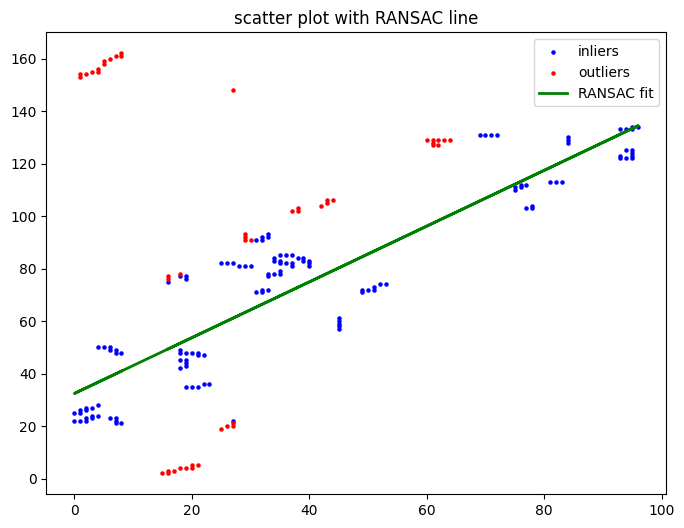

In [17]:
# 10. Estimate line using RANSAC 
x_reshaped = x.reshape(-1, 1) # RANSAC requires 2D array for X 
ransac = RANSACRegressor() 
ransac.fit(x_reshaped, y) 
#the slope and intercept 
m_ransac = ransac.estimator_.coef_[0] 
c_ransac = ransac.estimator_.intercept_ 
# Predict y values 
y_ransac = ransac.predict(x_reshaped) 
# Plott RANSAC 
inlier_mask = ransac.inlier_mask_ 
outlier_mask = np.logical_not(inlier_mask) 
plt.figure(figsize=(8, 6)) 
plt.scatter(x[inlier_mask], y[inlier_mask], s=5, color='blue', label='inliers') 
plt.scatter(x[outlier_mask], y[outlier_mask], s=5, color='red', label='outliers') 
plt.plot(x, y_ransac, color='green', linewidth=2, label='RANSAC fit') 
plt.title('scatter plot with RANSAC line') 
plt.legend() 
plt.show() 

In [18]:
# 11. Calculate the angle 
angle_ransac_rad = np.arctan(m_ransac) 
angle_ransac_deg = np.degrees(angle_ransac_rad) 
print(f"RANSAC estimated angle: {angle_ransac_deg:.2f} Degrees") 

RANSAC estimated angle: 46.73 Degrees
